In [1]:
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from utils import GradCAM, show_cam_on_image

from my_model_class import myAlexNet, myMobileNetV2, myHelper

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# model = myHelper.get_ResNet50_vd()
# model.load_state_dict(torch.load('C:\\Users\\hp\\Desktop\\model_res50vd_static.pth', map_location=device))
# model.eval()

# model = myMobileNetV2()
# model.load_state_dict(torch.load('C:\\Users\\hp\\Desktop\\model_mobilenet_v2_static.pth', map_location=device))
# model.eval()

model = myAlexNet()
model.load_state_dict(torch.load('C:\\Users\\hp\\Desktop\\model_alexnet_static.pth', map_location=device))
model.eval()

myAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)

In [3]:
 #设定目标层，softmax前最后一层，resnet50/101均为layer4
# target_layers = [model.layer4]

# target_layers = [model.features]

target_layers = [model.features]

In [4]:
data_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),                   
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

img_path = "E:\\datasets\\tire_dataset\\leb\\leb_1.jpg"
assert os.path.exists(img_path), "file: '{}' dose not exist.".format(img_path)

img1 = Image.open(img_path).convert('RGB')
k = transforms.Resize(224)
img2 = np.array(k(img1))


img1 = data_transform(img1)

input_batch = torch.unsqueeze(img1, dim=0) # [C, H, W] -> [N, C, H, W]
print(img2.shape)
print(input_batch.shape)

(224, 224, 3)
torch.Size([1, 3, 224, 224])


In [5]:
cam = GradCAM(model=model, target_layers=target_layers, use_cuda=False)

In [6]:
grayscale_cam = cam(input_tensor=input_batch)
print(grayscale_cam.shape)

category id: [2]
(1, 224, 224)


In [7]:
grayscale_cam = grayscale_cam[0, :]
print(grayscale_cam.shape, type(grayscale_cam))

(224, 224) <class 'numpy.ndarray'>


In [8]:
print(np.min(grayscale_cam)); print(np.max(grayscale_cam))

0.0
0.9999999


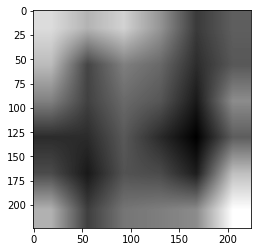

In [9]:
plt.imshow(grayscale_cam, cmap='gray')
plt.show()

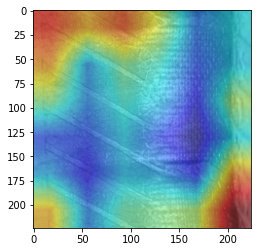

In [10]:
visualization = show_cam_on_image(img2 / 255.,
                                    grayscale_cam,
                                    use_rgb=True)
plt.imshow(visualization)
plt.show()


In [ ]:
print(visualization.shape)